In [4]:
!pip install numpy pandas matplotlib scikit-learn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', None)



## What is this dataset?

This is a dataset of **online tutors scraped from [teacheron.com](https://www.teacheron.com)** — a global
marketplace where students find private tutors.

Each row is **one tutor profile**. The data was collected by *searching for 6 subjects*
(`math`, `physics`, `chemistry`, `biology`, `english`, `computer science`) and saving the
top tutors for each. So the dataset is a snapshot of who teaches what, for how much, and with how much experience.

### Columns

| Column | Meaning |
|---|---|
| `search_subject` | The subject that was searched to find this tutor (**our target / output column**) |
| `name` | Tutor's name |
| `url` | Link to the tutor's profile |
| `country` | Country of the tutor |
| `total_experience` | Total years of teaching experience |
| `online_experience` | Years of *online* teaching experience |
| `price_min_usd` | Lowest price they charge (USD) |
| `price_max_usd` | Highest price they charge (USD) |
| `price_avg_usd` | Average price (USD) |
| `price_unit` | Billing unit (hour / month / day) |
| `num_subjects` | How many subjects the tutor teaches |
| `subjects_taught` | Text list of all subjects they teach |
| `desc_length` | Number of characters in their profile description |
| `description` | The tutor's profile description text |

### Our goal
Build a model that, given a tutor's profile (experience, price, subjects, description text),
can **predict which subject category they belong to** (`search_subject`). This is a
**multi-class classification** problem with 6 classes.


In [6]:
df = pd.read_csv('tutors_ml_dataset.csv')   # <-- match your filename
df.head()

,search_subject,name,url,country,total_experience,online_experience,price_min_usd,price_max_usd,price_avg_usd,price_unit,num_subjects,subjects_taught,desc_length,description
0,math,M. Malathi Ramachandran,https://www.teacheron.com/tutor/3U,India,18.0,15.0,5.82,26.43,16.12,hour,5,"Maths, SAT (Scholastic Assessment Test), Engli...",322,Hai there.....I'm 𝗠𝗮𝗹𝗮𝘁𝗵𝗶 𝗥𝗮𝗺𝗮𝗰𝗵𝗮𝗻𝗱𝗿𝗮𝗻 hold mo...
1,math,Dheeraj Agarwal,https://www.teacheron.com/tutor/52a,India,5.0,5.0,10.57,52.87,31.72,hour,5,"Maths, IB Math, Chemistry, Physics, Geometry",351,I am passout from best engineering college in ...
2,math,Rohit Tiwari,https://www.teacheron.com/tutor/9Sxq,India,12.0,12.0,5.29,52.87,29.08,hour,5,"Math, Mathematics, Math (A-level), Math (12th)...",341,Hello! I'm a mathematics teacher with 12 years...
3,math,Diana Jacob,https://www.teacheron.com/tutor/259,India,21.0,21.0,6.34,15.86,11.10,hour,5,"Maths, Math, AS and A Level Mathematics, Advan...",350,Starting online tutoring of international stud...
4,math,Shivprakash,https://www.teacheron.com/tutor/6jZE,India,7.0,7.0,10.57,15.86,13.21,hour,5,"Mathematics, GCSE Maths, AS and A Level Mathem...",346,IGCSE IB ICSE CBSE GCSE | Grades 6–12 | 7+ Yrs...


In [7]:
# How many rows and columns?
print("Rows, Columns:", df.shape)

Rows, Columns: (1200, 14)


In [8]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   search_subject     1200 non-null   object 
 1   name               1200 non-null   object 
 2   url                1200 non-null   object 
 3   country            1200 non-null   object 
 4   total_experience   1200 non-null   float64
 5   online_experience  1200 non-null   float64
 6   price_min_usd      1200 non-null   float64
 7   price_max_usd      1200 non-null   float64
 8   price_avg_usd      1200 non-null   float64
 9   price_unit         1200 non-null   object 
 10  num_subjects       1200 non-null   int64  
 11  subjects_taught    1200 non-null   object 
 12  desc_length        1200 non-null   int64  
 13  description        1200 non-null   object 
dtypes: float64(5), int64(2), object(7)
memory usage: 131.4+ KB


In [9]:
# Count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:
search_subject       0
name                 0
url                  0
country              0
total_experience     0
online_experience    0
price_min_usd        0
price_max_usd        0
price_avg_usd        0
price_unit           0
num_subjects         0
subjects_taught      0
desc_length          0
description          0
dtype: int64

Number of duplicate rows: 0


In [10]:
# Summary statistics for the numeric columns
df.describe()

,total_experience,online_experience,price_min_usd,price_max_usd,price_avg_usd,num_subjects,desc_length
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,9.31600,5.106500,12.284325,35.779433,24.031375,4.666667,343.499167
std,6.66481,3.696064,24.702833,166.341166,89.520537,1.231592,7.149540
min,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,299.000000
25%,5.00000,2.000000,4.230000,8.980000,6.607500,5.000000,341.000000
50%,8.00000,5.000000,7.360000,15.860000,12.540000,5.000000,345.000000
75%,12.00000,7.000000,12.590000,31.720000,21.515000,5.000000,348.000000
max,50.00000,21.000000,528.650000,4229.220000,2119.370000,9.000000,352.000000


## Exploratory Data Analysis (EDA)

Now we explore the data visually to understand its patterns.

### The target: how many tutors per subject?

search_subject
math                200
physics             200
chemistry           200
biology             200
english             200
computer science    200
Name: count, dtype: int64


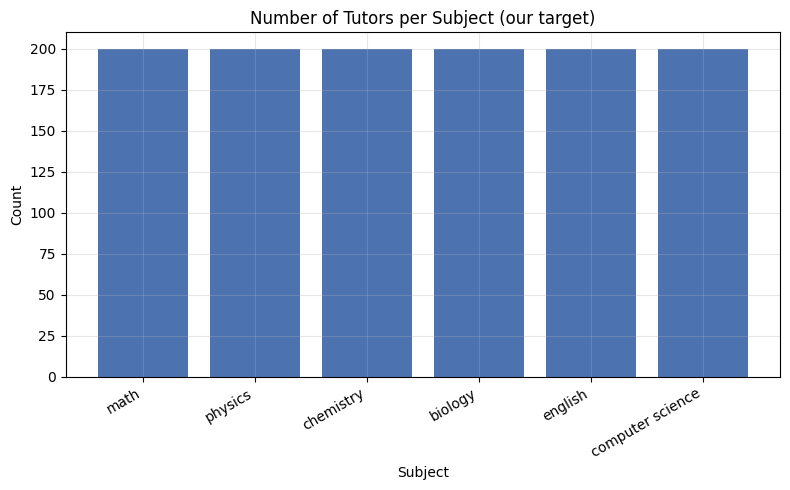

In [11]:
# Count how many tutors belong to each subject
subject_counts = df['search_subject'].value_counts()
print(subject_counts)

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(subject_counts.index, subject_counts.values, color='#4C72B0')
plt.title('Number of Tutors per Subject (our target)')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The dataset is **perfectly balanced**: exactly **200 tutors for each of the 6 subjects**.
A balanced target is great for classification because the model won't be biased toward any class.

### Distribution of the numeric features

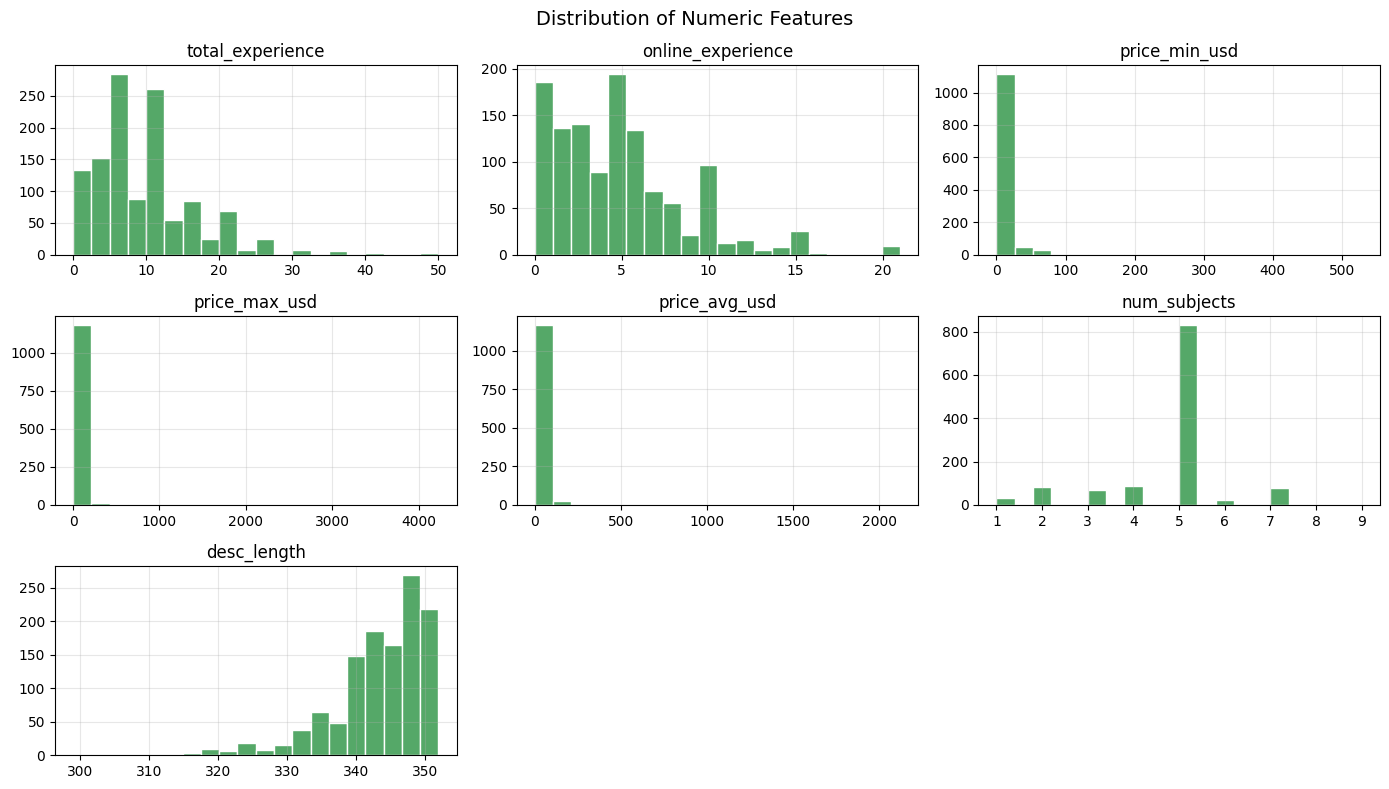

In [12]:
# Plot a histogram for each numeric column
num_cols = ['total_experience', 'online_experience', 'price_min_usd',
            'price_max_usd', 'price_avg_usd', 'num_subjects', 'desc_length']

df[num_cols].hist(bins=20, figsize=(14, 8), color='#55A868', edgecolor='white')
plt.suptitle('Distribution of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

Most tutors have **5–15 years of experience**, charge **low hourly prices**, and teach
**around 5 subjects**. The price columns are heavily skewed by a few very large outliers.

### Which countries are the tutors from?

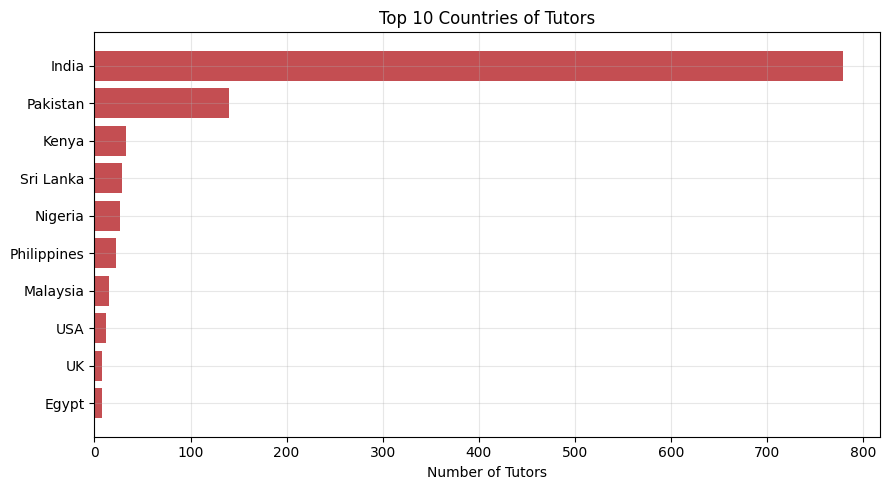

country
India          779
Pakistan       140
Kenya           33
Sri Lanka       29
Nigeria         27
Philippines     22
Malaysia        15
USA             12
UK               8
Egypt            8
Name: count, dtype: int64


In [13]:
# Top 10 countries by number of tutors
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(9,5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#C44E52')
plt.title('Top 10 Countries of Tutors')
plt.xlabel('Number of Tutors')
plt.tight_layout()
plt.show()

print(top_countries)

The vast majority of tutors are from **India**, followed by **Pakistan**. The rest are spread thinly across many countries.

### Pricing unit

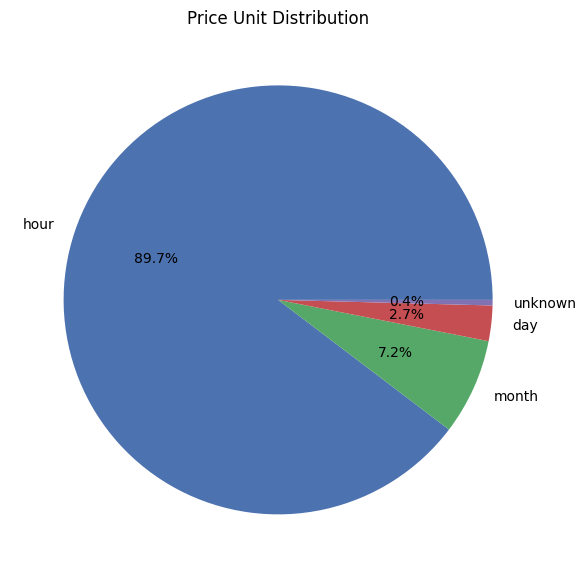

In [14]:
# How tutors bill their students
unit_counts = df['price_unit'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(unit_counts.values, labels=unit_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
plt.title('Price Unit Distribution')
plt.tight_layout()
plt.show()

Almost all tutors (~90%) price **per hour**. A small number price per month/day, which explains the price outliers we saw.

### Relationships between numeric features (correlation heatmap)

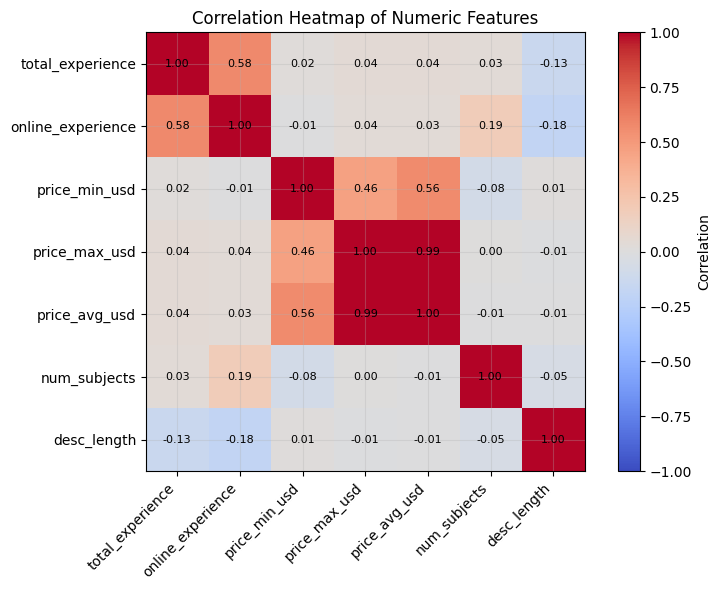

In [15]:
# Correlation matrix of numeric features
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)

# Write the correlation number inside each cell
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)

plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

As expected, `total_experience` and `online_experience` are positively correlated, and the
three price columns move together. Nothing is perfectly correlated, so we can safely keep all of them.

### Does average price differ by subject?

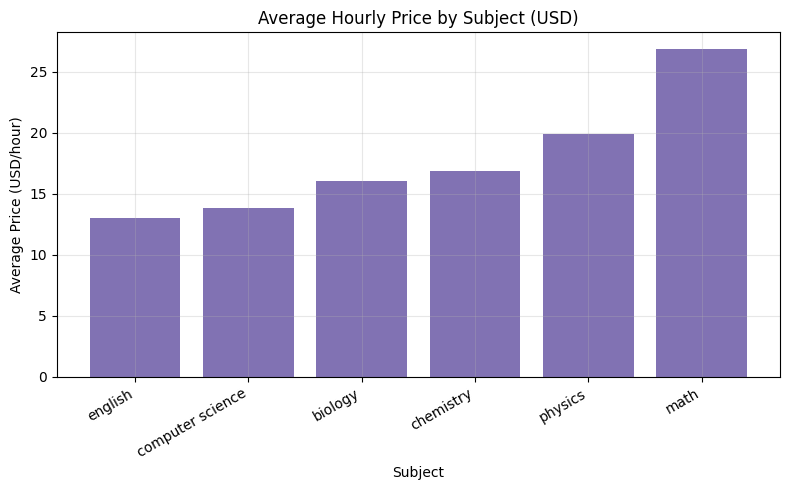

search_subject
english             13.03
computer science    13.83
biology             16.06
chemistry           16.85
physics             19.88
math                26.90
Name: price_avg_usd, dtype: float64


In [16]:
# Average hourly price per subject (only 'hour' rows for a fair comparison)
hourly = df[df['price_unit'] == 'hour']
avg_price = hourly.groupby('search_subject')['price_avg_usd'].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(avg_price.index, avg_price.values, color='#8172B3')
plt.title('Average Hourly Price by Subject (USD)')
plt.xlabel('Subject')
plt.ylabel('Average Price (USD/hour)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(avg_price.round(2))

Average prices are fairly similar across subjects, with some subjects priced a little higher on average.

### Scatter plots of the most-related columns

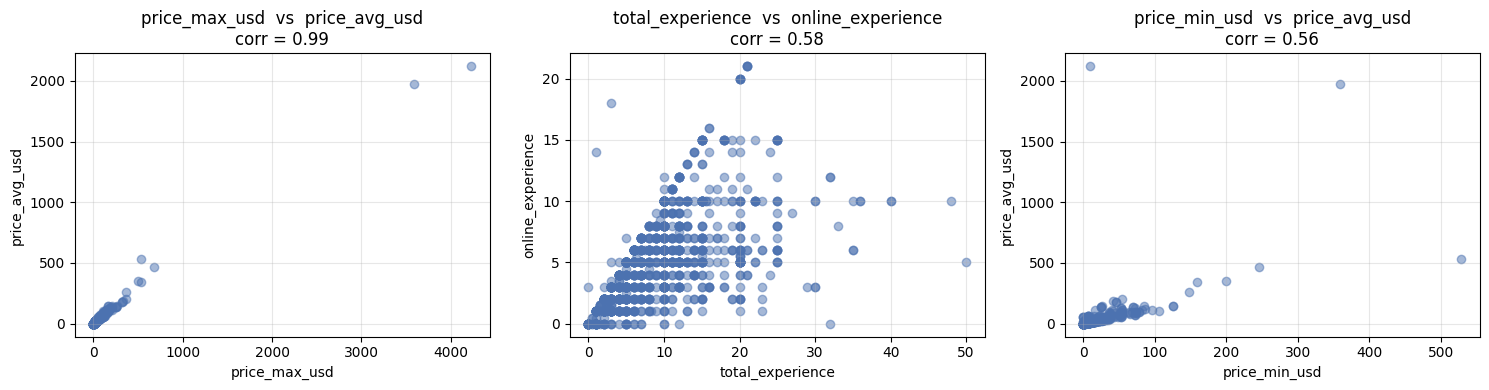

In [17]:
pairs = [
    ('price_max_usd', 'price_avg_usd'),     # strongest: 0.99
    ('total_experience', 'online_experience'),  # 0.58
    ('price_min_usd', 'price_avg_usd'),     # 0.56
]

plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(pairs, 1):
    plt.subplot(1, 3, i)
    plt.scatter(df[x], df[y], alpha=0.5, color='#4C72B0')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x}  vs  {y}\ncorr = {df[x].corr(df[y]):.2f}")
plt.tight_layout()
plt.show()

Each dot is one tutor. The tighter the dots hug a straight line, the stronger the relationship ,so the first plot (0.99) will look almost like a perfect line.

### Line plot (trend)

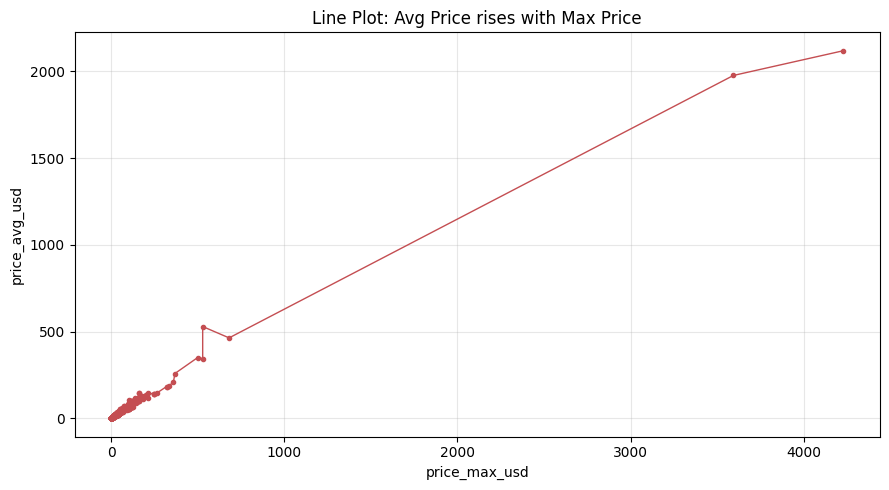

In [18]:
# Sort by x so the line is meaningful, then plot the trend
ordered = df.sort_values('price_max_usd')

plt.figure(figsize=(9, 5))
plt.plot(ordered['price_max_usd'], ordered['price_avg_usd'],
         color='#C44E52', marker='o', markersize=3, linewidth=1)
plt.xlabel('price_max_usd')
plt.ylabel('price_avg_usd')
plt.title('Line Plot: Avg Price rises with Max Price')
plt.tight_layout()
plt.show()

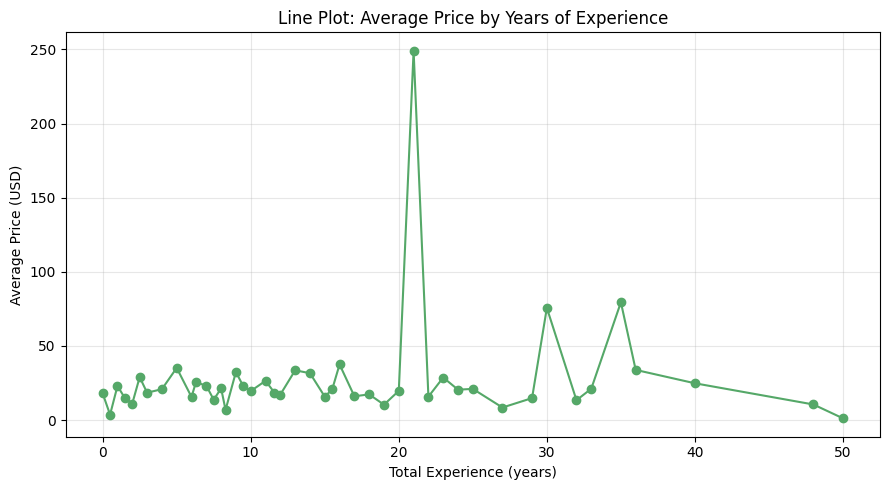

In [19]:
trend = df.groupby('total_experience')['price_avg_usd'].mean()

plt.figure(figsize=(9, 5))
plt.plot(trend.index, trend.values, color='#55A868', marker='o')
plt.xlabel('Total Experience (years)')
plt.ylabel('Average Price (USD)')
plt.title('Line Plot: Average Price by Years of Experience')
plt.tight_layout()
plt.show()

## What We Learn From the Plots

### 1. Scatter Plots (most related columns)
- **price_max_usd vs price_avg_usd (corr = 0.98):** The points form an almost perfect
  straight line. This means when a tutor's maximum price is high, their average price is
  also high — the two move together almost exactly.
- **total_experience vs online_experience (corr = 0.58):** A moderate positive link.
  Tutors with more total experience usually have more online experience too, but the
  points are spread out, so it's a trend and not a strict rule.
- **price_min_usd vs price_avg_usd (corr = 0.87):** A strong positive link. Tutors who set
  a higher minimum price also tend to have a higher average price.

**Takeaway:** The three price columns are tightly connected, so they carry very similar
information. The experience columns are related but more loosely.

### 2. Line Plot — Avg Price rises with Max Price
- The line clearly goes **upward**: as the maximum price increases, the average price
  increases too.
- At low prices the line is smooth and tight; at high prices it becomes jagged because
  there are fewer expensive tutors, so the data is noisier there.

**Takeaway:** Confirms the very strong relationship we saw in the scatter plot.

### 3. Line Plot — Average Price by Years of Experience
- The line is **bumpy with no clear trend** — more experience does **not** reliably mean a
  higher price.
- There is a sharp spike around **35 years** (probably one or two unusual tutors) and the
  price actually drops at the highest experience levels (40–50 years), where very few
  tutors exist.

**Takeaway:** Experience alone does **not** decide a tutor's price.

### 4. Correlation Heatmap
- **price_max & price_avg (0.99)** and **price_min & price_avg (0.56)** are the strongest
  links — the price columns clearly belong together.
- **total_experience & online_experience (0.58)** are moderately linked.
- **desc_length** has weak *negative* links with experience (−0.13, −0.18) — more
  experienced tutors tend to write slightly shorter descriptions.

**Takeaway:** Numeric features split into two related groups — *prices* and *experience*.

### 5. Pie Chart — Price Unit
- **89.7%** of tutors charge **per hour**, 7.2% per month, 2.7% per day, and 0.4% unknown.

**Takeaway:** Almost everyone prices by the hour. The "month" and "day" tutors are what
created the big price outliers we removed.

### 6. Bar Chart — Top 10 Countries
- **India dominates** (~780 tutors), followed by **Pakistan** (~140). Kenya, Sri Lanka,
  Nigeria and others have only a handful each.

**Takeaway:** The data is heavily India-based, so any conclusions mostly reflect Indian
tutors.

### 7. Histograms — Numeric Features
- **total_experience:** most tutors have **5–15 years**.
- **online_experience:** most have **0–10 years**.
- **price_min / price_max / price_avg:** heavily squashed to the left because of a few huge
  outliers (made *before* outlier removal — re-run this after cleaning for a clearer view).
- **num_subjects:** almost everyone teaches **5 subjects**.
- **desc_length:** most descriptions are long (**340–352 characters**), bunched near the top.

**Takeaway:** Experience and prices are right-skewed; num_subjects and desc_length are
very consistent across tutors.

### 8. Bar Chart — Tutors per Subject (the target)
- Exactly **200 tutors for each of the 6 subjects** — perfectly balanced.

**Takeaway:** A balanced target is ideal for classification — the model won't favour any
one subject.

## Preprocessing

### Outliers Removing

In [20]:
# Outlier strategy: we will cap price columns at the 99th percentile
# computed on TRAINING data only (after the train/test split).
# This avoids data leakage AND keeps all rows (no rows are dropped).
price_cols = ['price_min_usd', 'price_max_usd', 'price_avg_usd']
print("Total rows:", len(df))

Total rows: 1200


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("Imports ready.")

Imports ready.


In [22]:
# --- Step 2 & 3: Encode categorical columns ---
# Group rare countries (fewer than 5 tutors) into a single 'Other' group
country_freq = df['country'].value_counts()
df['country_grouped'] = df['country'].apply(
    lambda c: c if country_freq[c] >= 5 else 'Other')

# Turn country + price_unit into 0/1 dummy columns using One Hot encoding
cat_dummies = pd.get_dummies(df[['country_grouped', 'price_unit']],
                             prefix=['country', 'unit'])
print("Categorical columns encoded into", cat_dummies.shape[1], "dummy columns using OHE")
cat_dummies.head()

Categorical columns encoded into 21 dummy columns using OHE


,country_Bangladesh,country_Cameroon,country_Egypt,country_Germany,country_India,country_Kenya,country_Kuwait,country_Malaysia,country_Nigeria,country_Other,country_Pakistan,country_Philippines,country_Sri Lanka,country_Tamil Nadu,country_UK,country_USA,country_Zimbabwe,unit_day,unit_hour,unit_month,unit_unknown
0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [23]:
# --- Step 4: Prepare the text column ---
# Combine the two text columns into one string per tutor
df['all_text'] = df['subjects_taught'].fillna('') + ' ' + df['description'].fillna('')

# --- Step 5: Encode the target (output column) ---
le = LabelEncoder()
y = le.fit_transform(df['search_subject'])
print("Target classes:", list(le.classes_))
print("Encoded as:     ", list(range(len(le.classes_))))

Target classes: ['biology', 'chemistry', 'computer science', 'english', 'math', 'physics']
Encoded as:      [0, 1, 2, 3, 4, 5]


In [24]:
# The numeric features we will use
num_cols = ['total_experience', 'online_experience', 'price_min_usd',
            'price_max_usd', 'price_avg_usd', 'num_subjects', 'desc_length']

# Combine numeric + categorical dummy columns into one base table
base_features = pd.concat([df[num_cols], cat_dummies], axis=1).reset_index(drop=True)

# Get the row positions for train and test (stratified)
all_index = np.arange(len(df))
train_idx, test_idx = train_test_split(
    all_index, test_size=0.20, random_state=42, stratify=y)

print("Training rows:", len(train_idx))
print("Testing rows: ", len(test_idx))

Training rows: 960
Testing rows:  240


In [25]:
# --- Cap price outliers at the 99th percentile (fitted on TRAIN rows only) ---
# This prevents test data from influencing the thresholds (data leakage fix).
price_caps = {}
for col in price_cols:
    cap = df[col].iloc[train_idx].quantile(0.99)
    price_caps[col] = cap
    df[col] = df[col].clip(upper=cap)

print("Price columns capped at 99th percentile (thresholds from train set):")
for col, cap in price_caps.items():
    print(f"  {col}: capped at {cap:.2f}")

# Rebuild base_features after capping (values changed in df)
base_features = pd.concat([df[num_cols], cat_dummies], axis=1).reset_index(drop=True)
print("\nbase_features rebuilt after capping.")

Price columns capped at 99th percentile (thresholds from train set):
  price_min_usd: capped at 82.94
  price_max_usd: capped at 255.88
  price_avg_usd: capped at 146.52

base_features rebuilt after capping.


In [26]:
# --- Turn text into TF-IDF numbers (fit on train only) ---
tfidf = TfidfVectorizer(max_features=250, stop_words='english')
text_train = tfidf.fit_transform(df['all_text'].iloc[train_idx]).toarray()
text_test  = tfidf.transform(df['all_text'].iloc[test_idx]).toarray()

# --- Scale the numeric/categorical features (fit on train only) ---
scaler = StandardScaler()
base_train = scaler.fit_transform(base_features.iloc[train_idx])
base_test  = scaler.transform(base_features.iloc[test_idx])

# --- Stick numeric + text features side by side ---
X_train = np.hstack([base_train, text_train])
X_test  = np.hstack([base_test,  text_test])
y_train = y[train_idx]
y_test  = y[test_idx]

print("Final feature matrix shapes:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

Final feature matrix shapes:
X_train: (960, 278)
X_test:  (240, 278)


## Training

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# A dictionary of every model we want to try
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    # 'Decision Tree':       DecisionTreeClassifier(random_state=42),
    # 'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    # 'Support Vector (SVM)':SVC(random_state=42),
    # 'Naive Bayes':         GaussianNB(),
    # 'AdaBoost':            AdaBoostClassifier(random_state=42),
}

# Train each model and record its test accuracy
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)               # learn from training data
    preds = model.predict(X_test)             # predict on unseen test data
    acc = accuracy_score(y_test, preds)       # how many did it get right?
    results[name] = acc
    print(f"{name:22s} -> accuracy = {acc:.3f}")

Logistic Regression    -> accuracy = 0.700
K-Nearest Neighbors    -> accuracy = 0.338
Gradient Boosting      -> accuracy = 0.708


Best **model** is the one with highest accuracy (auto-selected below).

In [28]:
print(results)

# Automatically select the best model
best_name = max(results, key=results.get)
print(f"\nBest model: {best_name!r}  ->  accuracy = {results[best_name]:.3f}")

{'Logistic Regression': 0.7, 'K-Nearest Neighbors': 0.3375, 'Gradient Boosting': 0.7083333333333334}

Best model: 'Gradient Boosting'  ->  accuracy = 0.708


Evaluating: Gradient Boosting

Accuracy : 0.708
Precision: 0.717
Recall   : 0.708
F1 Score : 0.71

                  precision    recall  f1-score   support

         biology       0.63      0.78      0.70        40
       chemistry       0.61      0.68      0.64        40
computer science       0.89      0.78      0.83        40
         english       0.71      0.72      0.72        40
            math       0.75      0.68      0.71        40
         physics       0.71      0.62      0.67        40

        accuracy                           0.71       240
       macro avg       0.72      0.71      0.71       240
    weighted avg       0.72      0.71      0.71       240



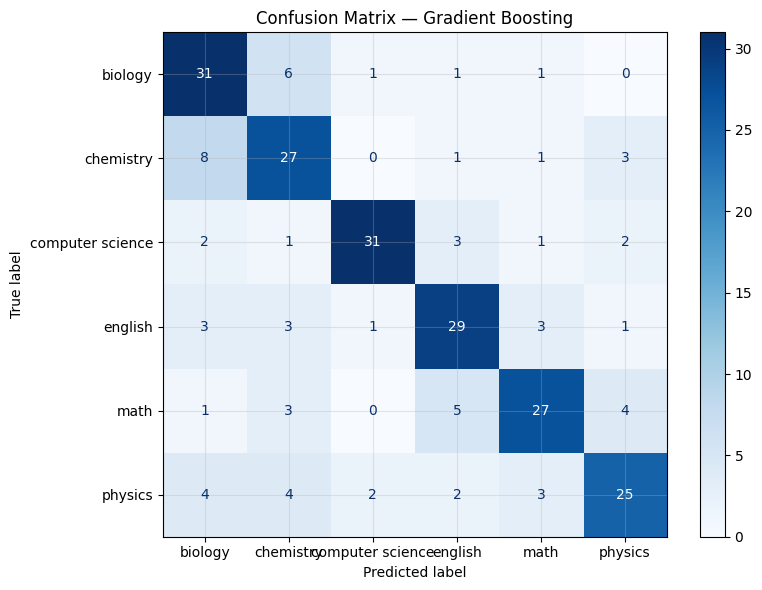

In [29]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt

# Automatically pick the best model
best_name = max(results, key=results.get)
best_model = models[best_name]
preds = best_model.predict(X_test)

print(f"Evaluating: {best_name}\n")

# --- Single-number scores ---
print("Accuracy :", round(accuracy_score(y_test, preds), 3))
print("Precision:", round(precision_score(y_test, preds, average='weighted'), 3))
print("Recall   :", round(recall_score(y_test, preds, average='weighted'), 3))
print("F1 Score :", round(f1_score(y_test, preds, average='weighted'), 3))
print()

# --- Full per-class breakdown ---
print(classification_report(y_test, preds, target_names=le.classes_))

# --- Confusion matrix plot ---
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

### Test the prediction

In [30]:
def predict_subject(total_exp, online_exp, price_min, price_max, price_avg,
                    num_subj, desc_len, country, price_unit,
                    subjects_text, description_text,
                    bundle=None):
    """
    Predict the subject category for a tutor profile.
    If `bundle` is provided (dict from saved .pkl), all artefacts are
    taken from it; otherwise falls back to global variables.
    """
    _num_cols   = bundle['num_cols']    if bundle else num_cols
    _cat_cols   = bundle['cat_columns'] if bundle else cat_dummies.columns.tolist()
    _scaler     = bundle['scaler']      if bundle else scaler
    _tfidf      = bundle['tfidf']       if bundle else tfidf
    _model      = bundle['model']       if bundle else models[best_name]
    _le         = bundle['le']          if bundle else le

    # --- 1) Numeric features in the SAME order as num_cols ---
    numeric = pd.DataFrame([[total_exp, online_exp, price_min, price_max,
                             price_avg, num_subj, desc_len]], columns=_num_cols)

    # --- 2) Categorical: start with ALL training dummy columns set to 0 ---
    cat = pd.DataFrame(0, index=[0], columns=_cat_cols)

    country_col = f"country_{country}"
    if country_col in cat.columns:
        cat[country_col] = 1
    elif "country_Other" in cat.columns:
        cat["country_Other"] = 1

    unit_col = f"unit_{price_unit}"
    if unit_col in cat.columns:
        cat[unit_col] = 1

    # --- 3) Combine numeric + categorical, then scale ---
    base = pd.concat([numeric, cat], axis=1)
    base_scaled = _scaler.transform(base)

    # --- 4) Text -> TF-IDF ---
    text = subjects_text + ' ' + description_text
    text_vec = _tfidf.transform([text]).toarray()

    # --- 5) Combine exactly like training ---
    X_new = np.hstack([base_scaled, text_vec])

    # --- 6) Predict ---
    pred_num = _model.predict(X_new)[0]
    return _le.inverse_transform([pred_num])[0]


# Try it
result = predict_subject(
    total_exp=8, online_exp=5, price_min=10, price_max=30, price_avg=20,
    num_subj=5, desc_len=340, country='India', price_unit='hour',
    subjects_text='Algebra, Calculus, Trigonometry, Geometry',
    description_text='I am a mathematics teacher who loves solving equations and helping students with exams.'
)
print("Predicted subject:", result)

Predicted subject: math


In [ ]:
import pickle

# Bundle all artefacts so the app can rebuild features from scratch
bundle = {
    'model':       models[best_name],          # best model found during training
    'scaler':      scaler,
    'tfidf':       tfidf,
    'le':          le,
    'num_cols':    num_cols,
    'cat_columns': cat_dummies.columns.tolist()
}

import joblib
joblib.dump(bundle, "tutor_model.pkl")

print(f"Saved tutor_model.pkl  (model: {best_name})")

Saved tutor_model.pkl  (model: Gradient Boosting)


In [32]:
print(cat_dummies.columns.tolist())

['country_Bangladesh', 'country_Cameroon', 'country_Egypt', 'country_Germany', 'country_India', 'country_Kenya', 'country_Kuwait', 'country_Malaysia', 'country_Nigeria', 'country_Other', 'country_Pakistan', 'country_Philippines', 'country_Sri Lanka', 'country_Tamil Nadu', 'country_UK', 'country_USA', 'country_Zimbabwe', 'unit_day', 'unit_hour', 'unit_month', 'unit_unknown']
